In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom8/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([5e2, 5e2, 5e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)

test_types = ['diff_of_gaussians','direct_mexican']
# test_type = 



The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:
num_cuda = cp.cuda.runtime.getDeviceCount()
devices = []
for i in range(0, num_cuda):
    devices += [f'cuda:{i}']

In [4]:
devices

['cuda:0']

In [5]:
epsilon = 1e-3
def extract_turbulent_scalar(snap, sf, variable, filter_length, weight, test_type, 
                             filter_type="mexican-hat", 
                             iterative=False, optimized=True):

    print("With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.")
    
    if (test_type=="direct_mexican"): 
        filt_var = sf.filter_variable(variable, filter_length, weight=weight, 
                                      filter_type="mexican-hat", iterative=iterative, optimized=optimized)
    
    elif (test_type=="diff_of_gaussians"): 
        filt_var_1 = sf.filter_variable(variable, filter_length/np.sqrt(1.0+epsilon), weight=weight, 
                                          filter_type="gaussian", iterative=iterative, optimized=True)
        filt_var_2 = sf.filter_variable(variable, filter_length*np.sqrt(1.0+epsilon), weight=weight, 
                                          filter_type="gaussian", iterative=iterative, optimized=True)
        filt_var = (filt_var_1 - filt_var_2)/epsilon

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))
    if isinstance(variable, str):
        variable = snap[variable]

        
    smoothVar = variable.copy
    turbVar = np.zeros_like(variable)
    
    smoothVar[sf.index] = filt_var
    turbVar[sf.index] = variable[sf.index] - filt_var

    return smoothVar, turbVar


In [6]:

def enforce_hermitian(amplitude_matrix):
    ## this is for odd matrices
    amplitudes = amplitude_matrix.copy()
    Nx, Ny, Nz = amplitudes.shape
    for kk in range(0,Nz//2):
        amplitudes[:,:,kk]=np.conj(np.flip(amplitudes)[:,:,kk])
    
    amplitudes[:Nx//2+1,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,:Ny//2+1,Nz//2])
    amplitudes[:Nx//2+1,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,:Ny//2+1,Nz//2])

    return amplitudes

In [7]:
# cp.cuda.Device(3).use()
# with cp.cuda.Device(3):

widths_slicer = widths.copy()
widths_slicer[2] = 0.
center_slicer = center.copy
slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=512)
extent = slicer.centered_extent.to('Mpc')

# Gauss = snap.uq('G')
arepo_length = snap['0_Diameters'].uq
density_unit = snap['0_Density'].uq
kpc = snap.uq('kpc')

weight = None

filter_lengths_vec = [40, 20, 10]

filter_length_max = filter_lengths_vec[0]*np.ones(snap['0_Diameters'].shape)*arepo_length

sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                        search_radius=4.1*filter_length_max.value)
# sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
#                         search_radius=filter_length_max.value)

npoints = 256
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=npoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="TSC")

Attempting to get derived variable: 0_Volume...	[DONE]

Attempting to get derived variable: 0_Diameters...	[DONE]



In [8]:
## generate Kolmogorov IC
nmax = 257
nfreq_tot = nmax**3
rng = np.random.default_rng(seed=456789)

x = snap['0_Coordinates'][sf.index][:, 0].value - center[0].value
y = snap['0_Coordinates'][sf.index][:, 1].value - center[1].value
z = snap['0_Coordinates'][sf.index][:, 2].value - center[2].value

kx_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[0])
ky_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[1])
kz_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[2])

KX, KY, KZ = np.meshgrid(kx_vec, ky_vec, kz_vec, sparse=False, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2 
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(nmax,nmax,nmax))

K2min = (2.0*np.pi/widths[0])**2 + (2.0*np.pi/widths[1])**2 + (2.0*np.pi/widths[2])**2
# K2min *=9
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
ampl = np.where(K2>0,np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
# ampl = np.where(K2==0,10.0,ampl)

amplitudes_rho = nfreq_tot*ampl*np.exp(1j*phases_rho)/(widths[0]*widths[1]*widths[2])        
amplitudes_rho = enforce_hermitian(amplitudes_rho)

synthetic_rhofield = np.zeros(snap['0_Density'].shape)
## redo this with finufft 
synthetic_rhofield[sf.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho, eps=1e-10, isign=-1))
# synthetic_rhofield[sf.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x), 
#                                                         ((2.0*np.pi/widths[1])*y), 
#                                                         ((2.0*np.pi/widths[2])*z), 
#                              amplitudes_rho, eps=1e-10, isign=-1))

snap['0_synthetic_rhofield'] = synthetic_rhofield * density_unit

/tmp/ipykernel_451632/1100571864.py:25: RuntimeWarning: divide by zero encountered in power
  ampl = np.where(K2>0,np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)


In [9]:
def chooseIC_and_filter_and_deposit(test_types, var_type="snap", filter_type="mexican-hat"):
    dict_tests = {}

    if (var_type=="snap"):
        var_str = "0_Density"
    elif (var_type=="synthetic"):
        var_str = '0_synthetic_rhofield'
    else:
        print("error: your var_type must either be 'snap' or 'synthetic'")
        return sliced_var_container
        
    # For the original field
    deposited_var_orig = depo.deposit_variable(var_str, weight='0_Volume')
    if (var_type=="snap"):
        powerspectr_orig, k1d_orig, _ = depo.power_spectrum1d(deposited_var_orig,
                                                window=scipy.signal.windows.hann)
    elif (var_type=="synthetic"):
        powerspectr_orig, k1d_orig, _ = depo.power_spectrum1d(deposited_var_orig)
    
    dict_tests['spectra_var_orig'] = (powerspectr_orig, k1d_orig)

    dict_tests['filtered'] = {}

    for i in range(len(filter_lengths_vec)):

        dict_test = {}
        name = '%d'%(filter_lengths_vec[i])

        filter_length = filter_lengths_vec[i]*np.ones(snap['0_Diameters'].shape)*arepo_length
    
        for j in range(len(test_types)):
            dict_test_type = {}
            
            test_type = test_types[j]
        
            # dict_test_type['test_type'] = test_type
        
            dict_test_type['var_type'] = var_str
        
            # For the filtered fields
            dict_test_type['var_container'] = {}
            
            
            rho_filtered, rho_remaining = extract_turbulent_scalar(snap, sf, 
                                                      var_str, 4.*filter_length, 
                                                      weight, test_type,
                                                                   filter_type, iterative=False)

            dict_test_type['filt_len'] = filter_lengths_vec[i]*arepo_length
            dict_test_type['sliced_var'] = slicer.slice_variable(rho_filtered)
            
            deposited_var = depo.deposit_variable(rho_filtered, weight='0_Volume')
            if (var_type=="snap"):
                powerspectr, k1d, _ = depo.power_spectrum1d(deposited_var,
                                                        window=scipy.signal.windows.hann)
            elif (var_type=="synthetic"):
                powerspectr, k1d, _ = depo.power_spectrum1d(deposited_var)

            dict_test_type['spectra_var'] = (powerspectr, k1d)

            dict_test[test_type] = dict_test_type

        dict_tests['filtered'][name] = dict_test
    
    return dict_tests
            

In [10]:
# dict_tests = chooseIC_and_filter_and_deposit(test_types, 
#                                 var_type="synthetic", 
#                                 filter_type="mexican-hat")

dict_tests = chooseIC_and_filter_and_deposit(test_types, 
                                var_type="snap", 
                                filter_type="mexican-hat")

energy (real space) = 7.1984e-02
energy (fourier space) = 2.8527e-01
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 4 / 0.15
energy (real space) = 1.4334e-03
energy (fourier space) = 1.7750e-02
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 4 / 0.15
energy (real space) = 1.5513e-03
energy (fourier space) = 1.8679e-02
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 4 / 0.15
energy (real space) = 3.6450e-04
energy (fourier space) = 4.1892e-03
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 4 / 0.15
energy (real space) = 4.2683e-04
energy (fourier space) = 4.7424e-03
With mexican-ha

In [11]:
for keys in dict_tests['filtered'].keys():
    print(dict_tests['filtered'][keys].keys())

dict_keys(['diff_of_gaussians', 'direct_mexican'])
dict_keys(['diff_of_gaussians', 'direct_mexican'])
dict_keys(['diff_of_gaussians', 'direct_mexican'])


In [15]:
def make_test_and_plot(dict_tests):

    for key in dict_tests['filtered'].keys():

        dict_test = dict_tests['filtered'][key]
        
        diff_gauss = dict_test['diff_of_gaussians']
        direct_mex = dict_test['direct_mexican']

        filt_len = diff_gauss['filt_len'].value
        var_type = diff_gauss['var_type']

        fig, ax = plt.subplots(1,3,figsize=(10,6), sharex=True, sharey=True)
        # i = n//2
        # j = n%2
        # effective_lambda = filt_len

        # if (filter_type == 'gaussian'):
        #     effective_lambda = np.sqrt(2.0)*np.pi*filt_len

        # elif (filter_type == 'mexican-hat'):
        #     effective_lambda = np.sqrt(2.0)*np.pi*filt_len
            
    
        vmax = np.max(np.abs(diff_gauss['sliced_var'].value))
        # vmin = np.max([np.min(np.abs(sliced_var_container[n,:,:])), 1e-2*vmax])
        # norm = LogNorm(vmin=vmin,vmax=vmax)
        # # cmap = cmr.fall
        # cmap = cmr.eclipse
        # if (var_type == "synthetic"):
        vmin = -vmax
        norm = Normalize(vmin=vmin,vmax=vmax)
        cmap = cmr.fusion_r
        
    
        im0 = ax[0].imshow(
            diff_gauss['sliced_var'].value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)
        im1 = ax[1].imshow(
            direct_mex['sliced_var'].value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)
        # im2 = ax[2].imshow(
        #     np.abs((diff_gauss['sliced_var']- direct_mex['sliced_var']).value), origin='lower', 
        #     norm=LogNorm(), cmap=cmr.eclipse, extent=extent.value)
        im2 = ax[2].imshow(
            np.abs((diff_gauss['sliced_var']- direct_mex['sliced_var']).value), origin='lower', 
            norm=norm, cmap=cmap, extent=extent.value)

        # ax[i,j].plot([-0.23,-0.23+effective_lambda/1e3],[-0.2,-0.2],color='k',lw=2.)
        # ax[i,j].plot([-0.2,-0.2+effective_lambda/1e3],[-0.17,-0.17],color='k',lw=2.)
        for i in range(3):
            ax[i].set_xlabel('x')
            ax[i].set_ylabel('z')
        
        ax[0].set_title('Diff of gaussians')
        ax[1].set_title('Direct mexican')
        ax[2].set_title('Error')
    
        cbar = fig.colorbar(im0, orientation='horizontal', shrink=0.7)
        cbar.set_label(r'$\delta \rho$')

        cbar = fig.colorbar(im1, orientation='horizontal', shrink=0.7)
        cbar.set_label(r'$\delta \rho$')

        cbar = fig.colorbar(im2, orientation='horizontal', shrink=0.7)
        cbar.set_label(r'$\delta \rho$')
    
        fig.suptitle('Comparison mexican hat var %s, l=%.1f'%(var_type, filt_len),fontsize=18)

        fig.subplots_adjust(top=0.9,
        bottom=0.1,
        left=0.1,
        right=0.9,
        hspace=0.15,
        wspace=0.0)

        savename = 'compare_%s_filt_len_%.2f'%(var_type, filt_len)
        plt.savefig('./../../plots/narrow-pass-filter/%s.pdf'%(savename), 
                    bbox_inches='tight', dpi=400)


    ## now spectra plots
    # fig, ax = plt.subplots(figsize=(8,6))

    # tt = np.logspace(np.log10(2e-2), 0, 100)

    # powerspectr_orig, k1d_orig = spectra_var_orig

    # ax.plot(k1d_orig.value, powerspectr_orig.value, ls='-', color=grays[6],
    #             markerfacecolor='none', label=r'original')
    # for n in range(len(filter_lengths_vec)):

    #     effective_lambda = filter_lengths_vec[n]

    #     if (filter_type == 'gaussian'):
    #         effective_lambda = np.sqrt(2.0)*np.pi*filter_lengths_vec[n]

    #     elif (filter_type == 'mexican-hat'):
    #         effective_lambda = np.sqrt(2.0)*np.pi*filter_lengths_vec[n]
            
    #     powerspectr, k1d = spectra_var_container[n]
    
    #     ax.plot(k1d.value, powerspectr.value, ls='-', color=reds[2*n],
    #             markerfacecolor='none', label=r'l=%.1f'%(filter_lengths_vec[n]))
        
    #     ax.vlines(2.0*np.pi/effective_lambda,ymin=1e-8,ymax=1e2, colors=reds[2*n], lw=1.)
    
    # ax.plot(tt, 1e-1*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')
    
    # ax.set_xlabel('$k$', fontsize=16)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_ylim(ymin=1e-8,ymax=1e2)
    
    # ax.legend(loc='best',ncols=1,fontsize=14)
    
    # ax.set_title(r'Energy Spectral Density %s for var %s'%(filter_type, var_type), fontsize=18)
    
    # # ax.set_xlim(xmin=1e-2)
    # # ax.set_ylim(ymin=1e-25,ymax=1e-11)
    # # ax.set_ylim(ymin=1e-20)
    # # ax[1].set_xlim(xmax=30)
    # savename = "power_spectrum_%s-%s"%(filter_type, var_type)
    
    # plt.savefig('./../../plots/narrow-pass-filter/%s/'%(test_type)+savename+'.pdf',dpi=400)


    
    # fig, ax = plt.subplots(figsize=(8,8), sharex=True, sharey=True)
    
    # # vmax = np.max(np.abs(deposited_var_orig.value))
    # # vmin = -vmax
    # # norm = Normalize(vmin=vmin,vmax=vmax)
    # # cmap = cmr.fusion

    # vmax = np.max(np.abs(deposited_var_orig.value))
    # vmin = np.max([np.min(np.abs(deposited_var_orig.value)), 1e-2*vmax])
    # norm = LogNorm(vmin=vmin,vmax=vmax)
    # # cmap = cmr.fall
    # cmap = cmr.eclipse
    # if (var_type == "synthetic"):
    #     vmin = -vmax
    #     norm = Normalize(vmin=vmin,vmax=vmax)
    #     cmap = cmr.fusion_r
        
    
    # im = ax.imshow(
    #     deposited_var_orig[:,:,npoints//2].value.T, origin='lower', norm=norm, cmap=cmap, extent=extent.value)
    
    # # ax[i,j].plot([-0.2,-0.2+filter_lengths_vec[n]/1e3],[-0.2,-0.2],color='w',lw=2.)
    # # ax[i,j].plot([-0.2,-0.2+effective_lambda/1e3],[-0.17,-0.17],color='k',lw=2.)
    # ax.set_xlabel('x')
    # ax.set_ylabel('z')
    
    # # ax[i,j].set_title('l=%.1f'%(filter_lengths_vec[n]))
    
    # cbar = fig.colorbar(im, orientation='horizontal', shrink=0.7)
    # cbar.set_label(r'$\rho$')
    
    # fig.suptitle('Original var %s'%(var_type),fontsize=18)
    
    # fig.subplots_adjust(top=0.9,
    # bottom=0.1,
    # left=0.1,
    # right=0.9,
    # hspace=0.15,
    # wspace=0.0)
    
    # savename = "original_var-%s"%(var_type)
    # plt.savefig('./../../plots/narrow-pass-filter/%s/'%(test_type)+savename+'.pdf',dpi=400)


    
    # plt.show()
    

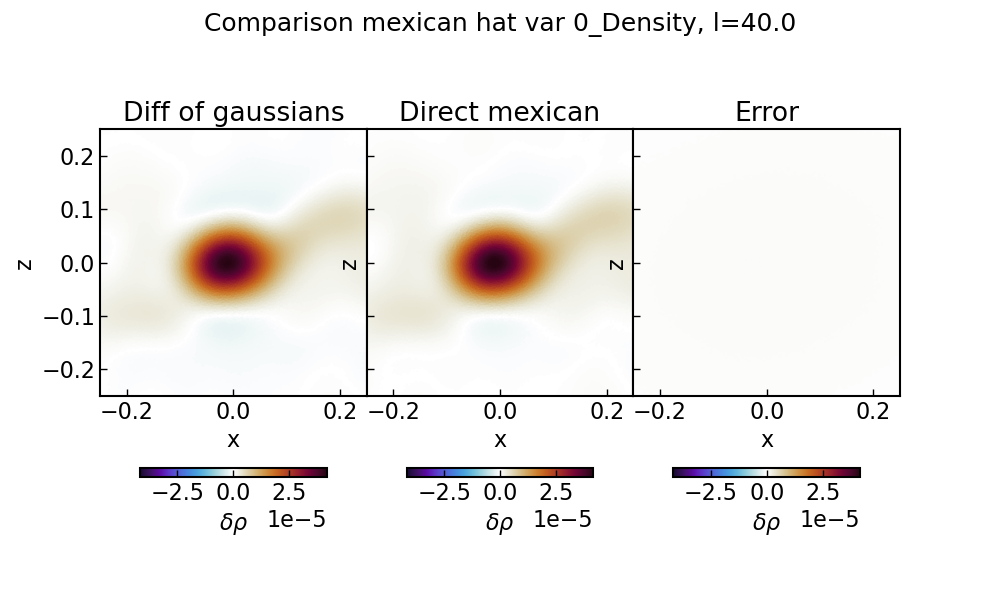

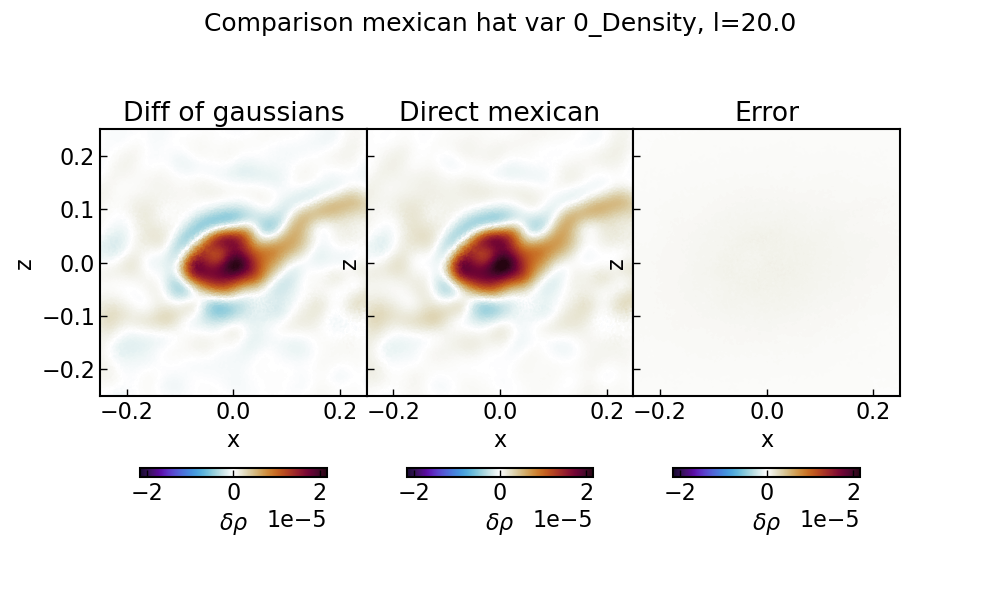

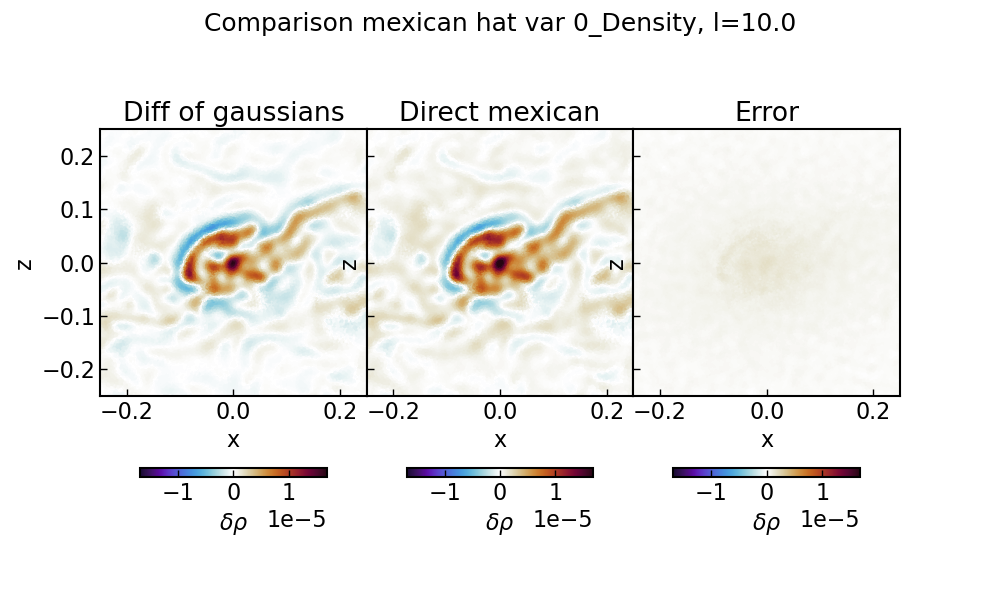

In [16]:
# for synthetic Kolmogorov spectrum with mexican filter
# sliced_var_synthetic_mexican, spectra_var_synthetic_mexican, deposited_var_orig, spectra_var_orig = chooseIC_and_filter_and_deposit(
#     var_type="snap",     filter_type='mexican-hat')
make_test_and_plot(dict_tests)

In [14]:
# for synthetic Kolmogorov spectrum with gaussian filter
# sliced_var_synthetic_gaussian, spectra_var_synthetic_gaussian, deposited_var_orig, spectra_var_orig = chooseIC_and_filter_and_deposit(
#     var_type="snap", filter_type='gaussian')
# make_test_and_plot(sliced_var_synthetic_gaussian, spectra_var_synthetic_gaussian, 
# deposited_var_orig, spectra_var_orig,
#                    var_type="snap",filter_type='gaussian')